## Prompt

> In combinatorial space of Freedom 5, find analogues of "c1ccc(CCNc2ncnc3ccccc23)cc1". Retain quinazoline part and modify attached amine. List 20 results. Retreieve cheapest possible molecules. Secondly, generate a 5x4 plot with retrieved structures.

In [1]:
import deepmedchem as dmc

DATABASE = "freedom-space-5"
# Retains the quinazolin-4-yl core (fused bicyclic ring system) and requires a carbon
# substituent on the exocyclic amine, so every hit actually varies that amine rather than
# leaving it as an unsubstituted NH2 while modifying something else in the molecule.
QUERY = "[#6]Nc1ncnc2ccccc12"
LIMIT = 200
TOP_N = 20

result = dmc.substructure(QUERY, database=DATABASE, limit=LIMIT, timeout_seconds=60)
print(f"{len(result.hits)} hits retain the quinazoline core with a substituted amine")

priced = [hit for hit in result.hits if hit.price is not None]
cheapest = sorted(priced, key=lambda hit: hit.price)[:TOP_N]

# Freedom Space 5 quotes a flat price per molecule at this scale, so all 200 hits tie at
# the same price -- "cheapest" doesn't discriminate among them here, this is just the
# top 20 by price (ascending) as requested.
for hit in cheapest:
    print(f"price=${hit.price}  {hit.smiles}")

200 hits retain the quinazoline core with a substituted amine
price=$250  CNc1ncnc2cc(C(=O)N(C)C3CC3)ccc12
price=$250  CN(C)c1ncnc2cc(C(=O)N(C)C3CC3)ccc12
price=$250  CN(C(=O)C1CCCN1c1ncnc2ccccc12)C1CC1
price=$250  CN(C(=O)c1cccc(Nc2ncnc3ccccc23)c1)C1CC1
price=$250  CNc1ncnc2cc(C(=O)N3CC3(C)C)ccc12
price=$250  CN(C)c1ncnc2cc(C(=O)N3CC3(C)C)ccc12
price=$250  CC1(C)CN1C(=O)C1CCCN1c1ncnc2ccccc12
price=$250  CC1(C)CN1C(=O)c1cccc(Nc2ncnc3ccccc23)c1
price=$250  CNc1ncnc2cc(C(=O)N3CC(O)C3)ccc12
price=$250  CN(C)c1ncnc2cc(C(=O)N3CC(O)C3)ccc12
price=$250  O=C(C1CCCN1c1ncnc2ccccc12)N1CC(O)C1
price=$250  O=C(c1cccc(Nc2ncnc3ccccc23)c1)N1CC(O)C1
price=$250  CNc1ncnc2cc(C(=O)N[C@@H]3C[C@H]3F)ccc12
price=$250  CN(C)c1ncnc2cc(C(=O)N[C@@H]3C[C@H]3F)ccc12
price=$250  O=C(N[C@@H]1C[C@H]1F)C1CCCN1c1ncnc2ccccc12
price=$250  O=C(N[C@@H]1C[C@H]1F)c1cccc(Nc2ncnc3ccccc23)c1
price=$250  CNc1ncnc2cc(C(=O)N3CCC3C)ccc12
price=$250  CC1CCN1C(=O)c1ccc2c(N(C)C)ncnc2c1
price=$250  CC1CCN1C(=O)C1CCCN1c1ncnc2ccccc12
pri

### Step 2 — 5x4 grid of the retrieved molecules

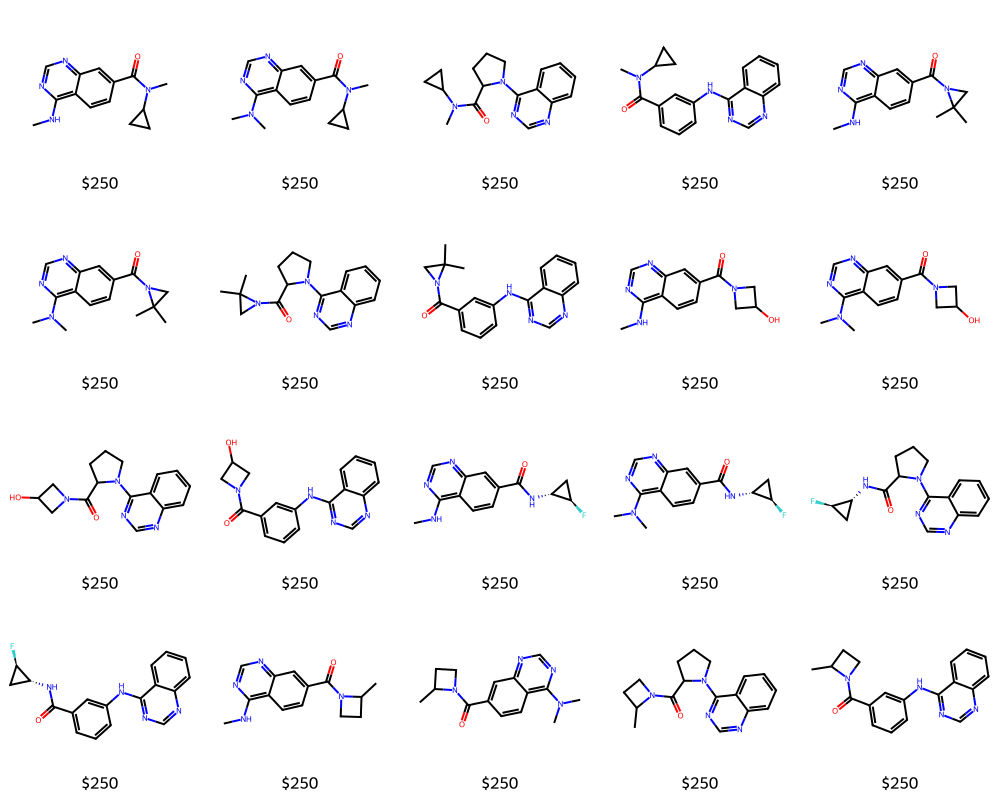

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(hit.smiles) for hit in cheapest]
legends = [f"${hit.price}" for hit in cheapest]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=legends)